<a href="https://colab.research.google.com/github/usman1911/DSA-Python/blob/main/Early_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install xgboost shap imbalanced-learn streamlit pyngrok joblib

In [2]:
from google.colab import files
uploaded = files.upload()

Saving covid_19_india.csv to covid_19_india (1).csv
Saving StatewiseTestingDetails.csv to StatewiseTestingDetails (1).csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

import shap
import joblib

In [4]:
cases = pd.read_csv("covid_19_india.csv")
tests = pd.read_csv("StatewiseTestingDetails.csv")

print("Cases shape:", cases.shape)
print("Tests shape:", tests.shape)

Cases shape: (18110, 9)
Tests shape: (16336, 5)


In [5]:
print("Cases columns:", list(cases.columns))
print("Tests columns:", list(tests.columns))

Cases columns: ['Sno', 'Date', 'Time', 'State/UnionTerritory', 'ConfirmedIndianNational', 'ConfirmedForeignNational', 'Cured', 'Deaths', 'Confirmed']
Tests columns: ['Date', 'State', 'TotalSamples', 'Negative', 'Positive']


In [6]:
# Cases
cases['Date'] = pd.to_datetime(cases['Date'], dayfirst=True, errors='coerce')
cases = cases.rename(columns={'State/UnionTerritory': 'State'})
cases = cases[['Date','State','Confirmed','Deaths','Cured']]

# Tests
tests['Date'] = pd.to_datetime(tests['Date'], errors='coerce')
tests = tests[['Date','State','TotalSamples']]
tests = tests.rename(columns={'TotalSamples':'Tested'})

cases.head(), tests.head()

(        Date   State  Confirmed  Deaths  Cured
 0 2020-01-30  Kerala          1       0      0
 1 2020-01-31  Kerala          1       0      0
 2 2020-02-01  Kerala          2       0      0
 3 2020-02-02  Kerala          3       0      0
 4 2020-02-03  Kerala          3       0      0,
         Date                        State  Tested
 0 2020-04-17  Andaman and Nicobar Islands  1403.0
 1 2020-04-24  Andaman and Nicobar Islands  2679.0
 2 2020-04-27  Andaman and Nicobar Islands  2848.0
 3 2020-05-01  Andaman and Nicobar Islands  3754.0
 4 2020-05-16  Andaman and Nicobar Islands  6677.0)

In [7]:
df = pd.merge(cases, tests, on=['Date','State'], how='left')
df.head()

,Date,State,Confirmed,Deaths,Cured,Tested
0,2020-01-30,Kerala,1,0,0,NaN
1,2020-01-31,Kerala,1,0,0,NaN
2,2020-02-01,Kerala,2,0,0,NaN
3,2020-02-02,Kerala,3,0,0,NaN
4,2020-02-03,Kerala,3,0,0,NaN


In [8]:
# forward-fill within each state for Tested
df['Tested'] = df.groupby('State')['Tested'].ffill()
df['Tested'] = df['Tested'].fillna(0)

df = df.sort_values(['State','Date']).reset_index(drop=True)
df.head()

,Date,State,Confirmed,Deaths,Cured,Tested
0,2020-03-26,Andaman and Nicobar Islands,1,0,0,0.0
1,2020-03-27,Andaman and Nicobar Islands,1,0,0,0.0
2,2020-03-28,Andaman and Nicobar Islands,6,0,0,0.0
3,2020-03-29,Andaman and Nicobar Islands,9,0,0,0.0
4,2020-03-30,Andaman and Nicobar Islands,9,0,0,0.0


In [9]:
# Lag features
df['lag_1'] = df.groupby('State')['Confirmed'].shift(1)
df['lag_7'] = df.groupby('State')['Confirmed'].shift(7)

# Rolling stats
df['rolling_mean_7'] = df.groupby('State')['Confirmed'].transform(lambda x: x.rolling(7).mean())
df['rolling_std_7']  = df.groupby('State')['Confirmed'].transform(lambda x: x.rolling(7).std())

# Growth & positivity (multi-signal fusion)
df['growth_rate'] = (df['Confirmed'] - df['lag_1']) / (df['lag_1'] + 1)
df['positivity_rate'] = df['Confirmed'] / (df['Tested'] + 1)

df[['State','Date','Confirmed','lag_1','lag_7','rolling_mean_7','rolling_std_7','growth_rate','positivity_rate']].head(10)

,State,Date,Confirmed,lag_1,lag_7,rolling_mean_7,rolling_std_7,growth_rate,positivity_rate
0,Andaman and Nicobar Islands,2020-03-26,1,NaN,NaN,NaN,NaN,NaN,1.0
1,Andaman and Nicobar Islands,2020-03-27,1,1.0,NaN,NaN,NaN,0.000000,1.0
2,Andaman and Nicobar Islands,2020-03-28,6,1.0,NaN,NaN,NaN,2.500000,6.0
3,Andaman and Nicobar Islands,2020-03-29,9,6.0,NaN,NaN,NaN,0.428571,9.0
4,Andaman and Nicobar Islands,2020-03-30,9,9.0,NaN,NaN,NaN,0.000000,9.0
5,Andaman and Nicobar Islands,2020-03-31,10,9.0,NaN,NaN,NaN,0.100000,10.0
6,Andaman and Nicobar Islands,2020-04-01,10,10.0,NaN,6.571429,4.035556,0.000000,10.0
7,Andaman and Nicobar Islands,2020-04-02,10,10.0,1.0,7.857143,3.338092,0.000000,10.0
8,Andaman and Nicobar Islands,2020-04-03,10,10.0,1.0,9.142857,1.463850,0.000000,10.0
9,Andaman and Nicobar Islands,2020-04-04,10,10.0,6.0,9.714286,0.487950,0.000000,10.0


In [10]:
# Predict if a surge occurs within next 7 days
df['future_cases'] = df.groupby('State')['Confirmed'].shift(-7)

# Global threshold (you can switch to adaptive threshold for publication)
threshold = df['Confirmed'].quantile(0.75)

df['target'] = (df['future_cases'] > threshold).astype(int)

df[['State','Date','Confirmed','future_cases','target']].tail(10)

,State,Date,Confirmed,future_cases,target
18101,West Bengal,2021-08-02,1528720,1533803.0,1
18102,West Bengal,2021-08-03,1529295,1534360.0,1
18103,West Bengal,2021-08-04,1530024,1534999.0,1
18104,West Bengal,2021-08-05,1530850,NaN,0
18105,West Bengal,2021-08-06,1531662,NaN,0
18106,West Bengal,2021-08-07,1532379,NaN,0
18107,West Bengal,2021-08-08,1533128,NaN,0
18108,West Bengal,2021-08-09,1533803,NaN,0
18109,West Bengal,2021-08-10,1534360,NaN,0
18110,West Bengal,2021-08-11,1534999,NaN,0


In [11]:
df = df.dropna().reset_index(drop=True)
df.shape

(17567, 14)

In [12]:
features = [
    'lag_1',
    'lag_7',
    'rolling_mean_7',
    'rolling_std_7',
    'growth_rate',
    'positivity_rate'
]

X = df[features]
y = df['target']

print("Positive class ratio:", y.mean())

Positive class ratio: 0.25667444640519155


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((14053, 6), (3514, 6))

In [14]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Before:", y_train.value_counts().to_dict())
print("After :", pd.Series(y_train_res).value_counts().to_dict())

Before: {0: 10446, 1: 3607}
After : {0: 10446, 1: 10446}


In [15]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train_res, y_train_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [16]:
pred = xgb.predict(X_test)
prob = xgb.predict_proba(X_test)[:,1]

print(classification_report(y_test, pred))
print("ROC AUC :", roc_auc_score(y_test, prob))
print("PR AUC  :", average_precision_score(y_test, prob))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2612
           1       0.99      1.00      1.00       902

    accuracy                           1.00      3514
   macro avg       1.00      1.00      1.00      3514
weighted avg       1.00      1.00      1.00      3514

ROC AUC : 0.9999804755808939
PR AUC  : 0.9999437417791694


In [17]:
def to_risk(p):
    if p < 0.3: return "Low"
    elif p < 0.6: return "Medium"
    else: return "High"

risk_labels = [to_risk(p) for p in prob]

results = X_test.copy()
results['probability'] = prob
results['risk'] = risk_labels

results.head(15)

,lag_1,lag_7,rolling_mean_7,rolling_std_7,growth_rate,positivity_rate,probability,risk
15251,2792.0,1991.0,2522.714286,288.820425,0.035446,2891.000000,0.000023,Low
1599,55496.0,41726.0,50401.714286,5366.197714,0.039966,0.043782,0.000054,Low
2461,7483.0,4673.0,6399.142857,1034.451453,0.016970,7610.000000,0.000016,Low
7716,908275.0,901410.0,905871.142857,2611.345019,0.001315,0.069312,0.999977,High
13943,316081.0,314682.0,315611.000000,486.946267,0.000636,0.055229,0.999979,High
9860,422118.0,366368.0,402464.000000,20478.936935,0.022745,0.191012,0.999973,High
9761,6430.0,3323.0,5234.714286,1154.647813,0.060177,0.067553,0.000027,Low
9241,259.0,104.0,249.857143,93.757539,0.707692,0.052014,0.000020,Low
13207,2986.0,2515.0,2818.714286,168.869490,0.025778,0.016809,0.000024,Low
2592,425.0,404.0,418.714286,7.825477,0.007042,0.057403,0.000015,Low


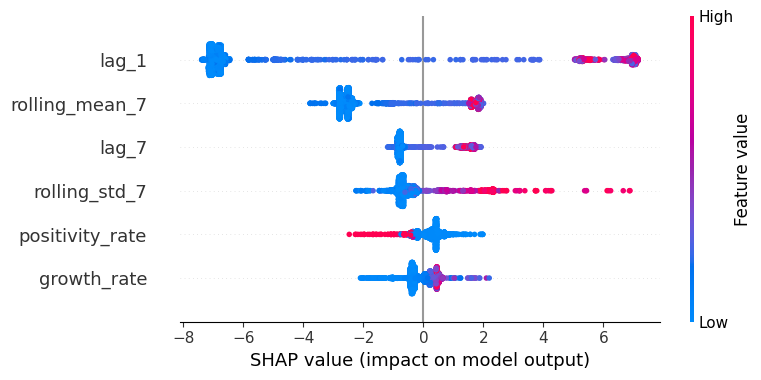

In [18]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

# Global importance
shap.summary_plot(shap_values, X_test)

Pred prob: 2.3434322e-05  | Risk: Low


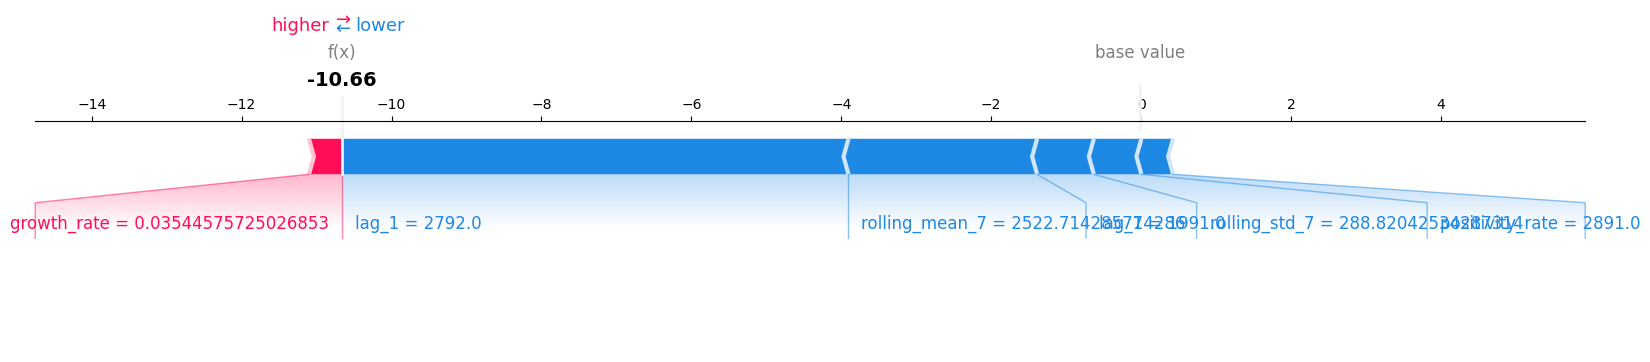

In [19]:
# Pick one example to explain
i = 0
print("Pred prob:", prob[i], " | Risk:", risk_labels[i])

shap.force_plot(
    explainer.expected_value,
    shap_values[i],
    X_test.iloc[i],
    matplotlib=True
)

In [20]:
joblib.dump(xgb, "xgb.pkl")
joblib.dump(features, "features.pkl")

print("Saved xgb.pkl and features.pkl")

Saved xgb.pkl and features.pkl


In [26]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import shap

# Load artifacts
model = joblib.load("xgb.pkl")
features = joblib.load("features.pkl")

# Initialize SHAP explainer
explainer = shap.TreeExplainer(model)

st.set_page_config(page_title="Outbreak Early Warning", layout="wide")

st.title("🔥 Epidemic Outbreak Early Warning Dashboard")

st.markdown("""
**Novelty highlights:**
- Rare-event early warning (7-day ahead)
- Multi-signal fusion (cases + testing → positivity)
- Imbalance-aware learning
- Interpretable risk tiers
""")

# Sidebar inputs
st.sidebar.header("Enter Surveillance Signals")

lag1 = st.sidebar.number_input("Lag-1 Cases", value=100.0)
lag7 = st.sidebar.number_input("Lag-7 Cases", value=90.0)
mean7 = st.sidebar.number_input("Rolling Mean (7d)", value=95.0)
std7 = st.sidebar.number_input("Rolling Std (7d)", value=15.0)
growth = st.sidebar.number_input("Growth Rate", value=0.10)
positivity = st.sidebar.number_input("Positivity Rate", value=0.05)

if st.sidebar.button("Predict Risk"):
    X = pd.DataFrame([[lag1, lag7, mean7, std7, growth, positivity]], columns=features)
    prob = model.predict_proba(X)[0][1]

    if prob < 0.3:
        risk = "Low"
    elif prob < 0.6:
        risk = "Medium"
    else:
        risk = "High"

    col1, col2 = st.columns(2)
    with col1:
        st.metric("Outbreak Probability", round(prob, 3))
        st.metric("Risk Level", risk)

    with col2:
        # Original feature bar plot
        fig_features, ax_features = plt.subplots()
        ax_features.bar(features, [lag1, lag7, mean7, std7, growth, positivity])
        ax_features.set_xticks(range(len(features)))
        ax_features.set_xticklabels(features, rotation=45, ha='right')
        ax_features.set_title('Input Feature Values')
        st.pyplot(fig_features)

    st.success("Prediction complete. Use for early-warning decisions.")

    st.markdown("### How Each Feature Contributes (SHAP Values):")

    # Calculate SHAP values for the single input instance
    shap_values = explainer.shap_values(X)

    # Plot SHAP force plot
    # Ensure SHAP plot is captured correctly by matplotlib
    fig_shap = shap.force_plot(
        explainer.expected_value,
        shap_values[0],
        X.iloc[0],
        matplotlib=True,
        show=False # Prevent immediate display, let streamlit handle it
    )
    st.pyplot(fig_shap, bbox_inches='tight') # Use bbox_inches to prevent clipping

else:
    st.info("Enter values on the left and click **Predict Risk**.")


Overwriting app.py


In [22]:
from pyngrok import ngrok

ngrok.set_auth_token("3Cv0X0VrtIpFHTsoFyeEwKo3rbe_3pK4mkHim8QDr425toyfX")

In [23]:
!streamlit run app.py &>/content/logs.txt &

In [27]:
from pyngrok import ngrok
import time

# Terminate all ngrok processes at the OS level to ensure no lingering connections
!killall ngrok
time.sleep(5) # Give more time for processes to terminate

ngrok.kill() # Kill pyngrok-managed processes as a fallback
time.sleep(2) # Add a short delay to ensure ngrok processes are killed
public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://early-canon-animating.ngrok-free.dev" -> "http://localhost:8501"
